# 18 — Final trio dashboard: return per unit of risk

One-page visual companion to the `15_2` final comparison. Three lines, one
common window (2019-01-03 → 2026-01-30, each re-based at the window start):

- **Static B&H 16-26** — the raw-return benchmark,
- **Factor ext26** — the date-as-of macro-factor line (no SJM),
- **SJM×crowding de-risk v2 ext26** — the drawdown-armed overlay (nb17).

The question the dashboard answers is not "who made the most money" (static
B&H does, with the deepest drawdown) but **how much return each line earns per
unit of risk taken** — total volatility, drawdown, and residual risk under a
single-factor raw-return SPY regression.

Everything recomputes offline from the persisted artifacts with the same
conventions as `15_2` — literally the same code: metrics come from the shared
`macro_framework.evaluation.metric_block`, stability from
`macro_framework.ssr.ssr_inference`. The headline numbers are pinned by
assertions against the `15_2` export — if an artifact drifts, this notebook
fails loudly instead of plotting stale claims.

> Caveats inherited from `15_2`: SPY is price-only (dividends missing), so the
> regression intercept and residual-risk numbers depend on that benchmark choice.
> They remain useful as internal, same-source comparisons, but they are not
> excess-return CAPM/Jensen-alpha claims. SSR is reported as a descriptive
> stability effect size *with* its one-sided MBB p-value and verdict — the
> estimate alone is not a ranking and is never plotted as one. Realized
> simulation curves only, no forecast-accuracy claims.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "workbook"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from macro_framework import skill_metric as sk
# same shared metric block as 15_2 — one convention for the repo, keys and all
from macro_framework.evaluation import TRADING_DAYS, metric_block
# ssr_inference, never bare compute_ssr: SSR on its own is an effect size with no
# sampling distribution attached. The MBB p-value/verdict carries the claim.
from macro_framework.ssr import ssr_inference

DATA = REPO / "data"

TRIO = [
    ("static_bh_equity_2016_2026", "Static B&H 16-26", "#2f6db3"),
    ("factor_equity_ext2026", "Factor ext26", "#e8710a"),
    ("sjm_crowding_derisk_v2_equity_ext2026", "SJM×crowding de-risk v2 ext26", "#8656c9"),
]


def active_value(value):
    moving = value[value.ne(value.iloc[0])]
    if moving.empty:
        return value
    first_move = moving.index.min()
    prior = value.index[value.index < first_move]
    return value.loc[(prior.max() if len(prior) else first_move):]


vals = {lbl: active_value(pd.read_parquet(DATA / f"{stem}.parquet")["value"])
        for stem, lbl, _ in TRIO}
t_start = max(v.index.min() for v in vals.values())
t_end = min(v.index.max() for v in vals.values())
spy_px = pd.read_parquet(DATA / "etf_prices_wide_2013_2026.parquet")["SPY"].dropna()
print(f"common window: {t_start:%Y-%m-%d} → {t_end:%Y-%m-%d}")
print(f"regression factor sample ends: {spy_px.index.max():%Y-%m-%d}")

M = {}
for stem, lbl, color in TRIO:
    v = vals[lbl].loc[t_start:t_end]
    mb = metric_block(v)
    r = mb["returns"]
    spx = sk.basket_residual(r, spy_px.pct_change().rename("SPY").to_frame("SPY"), periods_per_year=TRADING_DAYS)
    inf = ssr_inference(r)
    M[lbl] = {"color": color, "cagr": mb["cagr"], "ann_vol": mb["ann_vol"],
              "sharpe": mb["sharpe"], "maxdd": mb["maxdd"], "calmar": mb["calmar"],
              "alpha": float(spx.alpha_ann), "idio": float(spx.idio_vol_ann),
              "appraisal": float(spx.appraisal) if spx.appraisal is not None else np.nan,
              "ssr": float(inf.result.ssr), "ssr_p": float(inf.p_value),
              "ssr_verdict": inf.verdict()}

# provenance check: reuse the already generated trio tear-sheet export rather than
# pinning older headline numbers that depended on a different annualization basis.
# 15_2 writes that CSV at %.8f, so 5e-9 is its representation floor — anything
# tighter fails on rounding, anything looser would let real drift through.
TOL = 5e-9  # == %.8f's half-ulp; bound is inclusive by design
trio_csv = DATA / "tear_sheet" / "tear_sheet_trio_ext2026.csv"
if trio_csv.exists():
    trio = pd.read_csv(trio_csv).set_index("Label")
    PINS = [("cagr", "CAGR"), ("ann_vol", "Ann. Volatility"), ("sharpe", "Sharpe"),
            ("maxdd", "Max Drawdown"), ("calmar", "Calmar"),
            ("alpha", "Regression intercept (ann.)"),
            ("idio", "Residual vol (ann., SPY reg)"),
            ("appraisal", "Appraisal Ratio (intercept / residual vol)"),
            # SSR and its p-value are pinned too: both notebooks route through
            # ssr_inference, so a mismatch means one of them re-encoded the statistic.
            ("ssr", "SSR (Sharpe Stability Ratio)"),
            ("ssr_p", "SSR MBB p (one-sided)")]
    for lbl in [lbl for _, lbl, _ in TRIO]:
        row = trio.loc[lbl]
        for key, col in PINS:
            assert abs(M[lbl][key] - float(row[col])) <= TOL, (lbl, key, M[lbl][key], row[col])
    print(f"self-check vs {trio_csv.name}: PASS ({len(PINS)} pins × {len(TRIO)} lines)")
else:
    print("tear_sheet_trio_ext2026.csv missing — self-check skipped")

print("\nSSR — descriptive effect size + the one-sided MBB verdict that carries the claim:")
for _, lbl, _ in TRIO:
    print(f"  {lbl}: {M[lbl]['ssr_verdict']}")

tbl = pd.DataFrame(M).T.drop(columns=["color", "ssr_verdict"])
tbl.columns = ["CAGR", "Ann. vol σ", "Sharpe (rf=0)", "Max DD", "Calmar",
               "Regression intercept (ann.)", "Residual vol σε", "Appraisal",
               "SSR (effect size, not rankable)", "SSR MBB p (one-sided)"]
tbl.style.format({"CAGR": "{:.1%}", "Ann. vol σ": "{:.1%}", "Max DD": "{:.1%}",
                  "Regression intercept (ann.)": "{:.1%}", "Residual vol σε": "{:.1%}", "Sharpe (rf=0)": "{:.2f}",
                  "Calmar": "{:.2f}", "Appraisal": "{:.2f}",
                  "SSR (effect size, not rankable)": "{:.2f}", "SSR MBB p (one-sided)": "{:.3f}"})

common window: 2019-01-02 → 2026-01-30
regression factor sample ends: 2026-05-28


self-check vs tear_sheet_trio_ext2026.csv: PASS (10 pins × 3 lines)

SSR — descriptive effect size + the one-sided MBB verdict that carries the claim:
  Static B&H 16-26: SSR=0.14: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.000 < 0.05) — temporal consistency, not a skill claim
  Factor ext26: SSR=0.13: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.000 < 0.05) — temporal consistency, not a skill claim
  SJM×crowding de-risk v2 ext26: SSR=0.13: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.000 < 0.05) — temporal consistency, not a skill claim


,CAGR,Ann. vol σ,Sharpe (rf=0),Max DD,Calmar,Regression intercept (ann.),Residual vol σε,Appraisal,"SSR (effect size, not rankable)",SSR MBB p (one-sided)
Static B&H 16-26,18.1%,14.6%,1.23,-19.6%,0.92,8.1%,7.6%,1.06,0.14,0.000
Factor ext26,13.7%,9.2%,1.48,-12.1%,1.14,10.0%,8.0%,1.24,0.13,0.000
SJM×crowding de-risk v2 ext26,13.0%,8.1%,1.57,-8.4%,1.55,10.1%,7.4%,1.37,0.13,0.000


## 1. Risk–return maps — where each line sits, and what a unit of risk buys

Both panels put **risk on x, return on y**, with gray reference rays from the
origin: every point on a ray earns the same return per unit of risk, and
steeper is better. Left: total risk (CAGR against annualized volatility, rays
= CAGR/σ — the geometric cousin of a raw-return Sharpe; the exact ratio is in
each label). Right: regression-adjusted (annualized raw-return SPY-regression
intercept against residual volatility σε, rays = the appraisal ratio exactly).

Static B&H sits far right: more return, bought with much more risk. The two
factor lines sit upper-left of it on both maps — and the v2 overlay is the
only line that *reduces* risk (σ and σε) while holding the regression intercept
roughly constant.

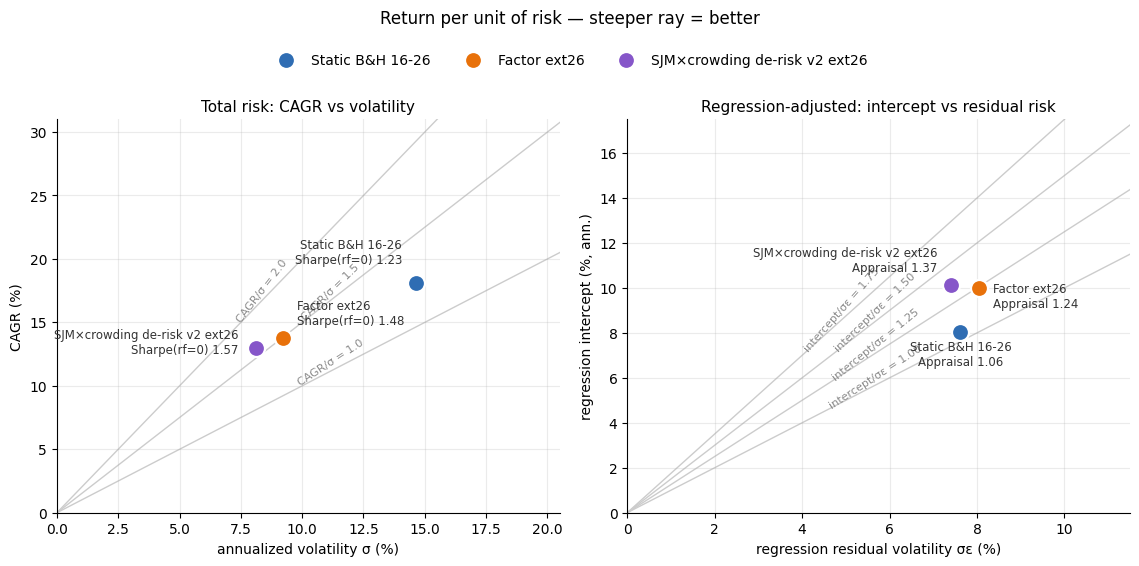

In [2]:
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
INK, MUTED = "#333333", "#8a8a8a"

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.5, 5.2))

def ray_panel(ax, slopes, slope_fmt, xmax, ymax, frac):
    ax.set_xlim(0, xmax); ax.set_ylim(0, ymax)
    ax.grid(alpha=0.25, zorder=0)
    for s in slopes:
        ax.plot([0, xmax], [0, s * xmax], color="#cccccc", lw=1, zorder=1)
        xe = min(xmax, ymax / s)
        p0 = ax.transData.transform((0.0, 0.0))
        p1 = ax.transData.transform((xe, s * xe))
        ang = np.degrees(np.arctan2(p1[1] - p0[1], p1[0] - p0[0]))
        ax.annotate(slope_fmt.format(s), (frac * xe, frac * s * xe), color=MUTED,
                    fontsize=8, ha="center", va="bottom", rotation=ang,
                    rotation_mode="anchor", xytext=(0, 2), textcoords="offset points")

XA, YA = 20.5, 31.0
ray_panel(axA, (1.0, 1.5, 2.0), "CAGR/σ = {:.1f}", XA, YA, frac=0.55)
offA = {"Static B&H 16-26": (-10, 14), "Factor ext26": (10, 10), "SJM×crowding de-risk v2 ext26": (-13, -4)}
for lbl, d in M.items():
    x, y = d["ann_vol"] * 100, d["cagr"] * 100
    axA.scatter(x, y, s=150, color=d["color"], edgecolor="white", linewidth=1.6, zorder=3, label=lbl)
    axA.annotate(f"{lbl}\nSharpe(rf=0) {d['sharpe']:.2f}", (x, y), xytext=offA[lbl],
                 textcoords="offset points", fontsize=8.5, color=INK,
                 ha="center" if offA[lbl][0] == 0 else ("left" if offA[lbl][0] > 0 else "right"))
axA.set_xlabel("annualized volatility σ (%)"); axA.set_ylabel("CAGR (%)")
axA.set_title("Total risk: CAGR vs volatility", fontsize=11)

XB, YB = 11.5, 17.5
ray_panel(axB, (1.0, 1.25, 1.5, 1.75), "intercept/σε = {:.2f}", XB, YB, frac=0.50)
offB = {"Static B&H 16-26": (0, -24), "Factor ext26": (10, -14), "SJM×crowding de-risk v2 ext26": (-10, 10)}
for lbl, d in M.items():
    x, y = d["idio"] * 100, d["alpha"] * 100
    axB.scatter(x, y, s=150, color=d["color"], edgecolor="white", linewidth=1.6, zorder=3)
    axB.annotate(f"{lbl}\nAppraisal {d['appraisal']:.2f}", (x, y), xytext=offB[lbl],
                 textcoords="offset points", fontsize=8.5, color=INK,
                 ha="center" if offB[lbl][0] == 0 else ("left" if offB[lbl][0] > 0 else "right"))
axB.set_xlabel("regression residual volatility σε (%)"); axB.set_ylabel("regression intercept (%, ann.)")
axB.set_title("Regression-adjusted: intercept vs residual risk", fontsize=11)

fig.legend(loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Return per unit of risk — steeper ray = better", y=1.08, fontsize=12)
fig.tight_layout()
fig.savefig(DATA / "nb18_risk_return_maps.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. The ratio ladder — three risk denominators, one axis

Each row divides return by a different risk: total volatility (**Sharpe, rf=0**),
worst peak-to-trough loss (**Calmar** = CAGR/|max DD|), and regression residual
volatility (**Appraisal** = intercept/σε). All three are unitless, so they share one
axis. The ordering is the finding: static B&H is last on every denominator,
and the v2 overlay leads on every one — its edge is widest on Calmar (1.55 vs
1.14 for the unhedged base), which is exactly the risk the drawdown-armed design
targets.

> **That ordering is scoped to this window, and since the 2026-07-27 artifact
> regeneration the window end is load-bearing.** The trio stops at 2026-01-30
> because that is where the static B&H series ends. The overlay's own line runs to
> 2026-06-30, and its deepest drawdown on that full span is a **new episode that
> starts two days after this window closes** — peak 2026-01-28, trough 2026-03-26,
> −11.24%, against −11.76% for the unhedged base over the same stretch. On the full
> 2019–2026 span the overlay therefore keeps its Sharpe edge (1.49 vs 1.43) and
> still ends shallower on max drawdown (−11.24% vs −12.08%), but its Calmar
> (**1.147**) lands marginally *below* the base line's (**1.153**) — the Calmar lead
> shown on this ladder does not survive to 2026-06. Under the superseded 2026-07-23
> artifact it did (full-span maxDD −10.32%, Calmar 1.270). Read the ladder as a
> statement about 2019-01→2026-01, not as a property of the overlay.


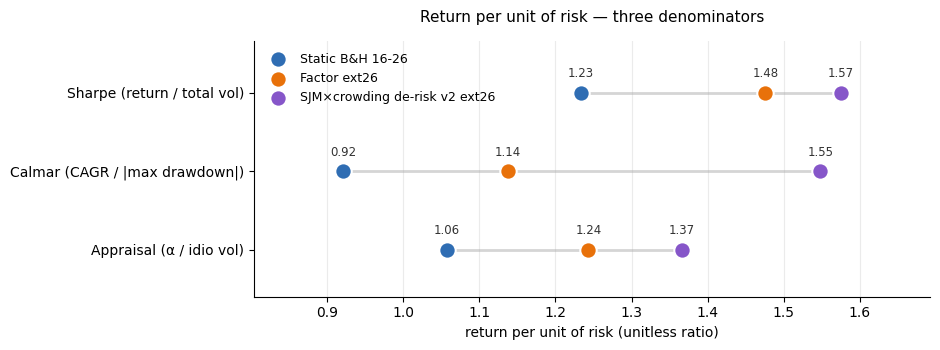

In [3]:
RATIOS = [("Sharpe (return / total vol)", "sharpe"),
          ("Calmar (CAGR / |max drawdown|)", "calmar"),
          ("Appraisal (α / idio vol)", "appraisal")]

fig, ax = plt.subplots(figsize=(9.5, 3.6))
for i, (row_lbl, key) in enumerate(RATIOS):
    y = len(RATIOS) - 1 - i
    xs = [M[lbl][key] for _, lbl, _ in TRIO]
    ax.plot([min(xs), max(xs)], [y, y], color="#d5d5d5", lw=2, zorder=1)
    for _, lbl, _ in TRIO:
        d = M[lbl]
        ax.scatter(d[key], y, s=140, color=d["color"], edgecolor="white",
                   linewidth=1.5, zorder=3, label=lbl if i == 0 else None)
        ax.annotate(f"{d[key]:.2f}", (d[key], y), xytext=(0, 11),
                    textcoords="offset points", ha="center", fontsize=8.5, color=INK)
ax.set_yticks(range(len(RATIOS)), [r for r, _ in reversed(RATIOS)])
ax.set_xlabel("return per unit of risk (unitless ratio)")
# limits from the DATA, not hardcoded: a hardcoded window silently clips points when
# the metric basis changes (it was hiding static B&H's Calmar and Appraisal).
_all = [M[lbl][k] for _, lbl, _ in TRIO for _, k in RATIOS]
_pad = 0.18 * (max(_all) - min(_all))
ax.set_xlim(min(_all) - _pad, max(_all) + _pad)
ax.grid(axis="x", alpha=0.25, zorder=0)
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.set_ylim(-0.6, 2.65)
ax.set_title("Return per unit of risk — three denominators", fontsize=11, pad=14)
fig.tight_layout()
fig.savefig(DATA / "nb18_ratio_ladder.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Metric profile — the six rankable headline metrics on one display

Parallel-coordinates profile: one vertical axis per metric, one line per
strategy, real values at each node. Every axis is oriented so that **up =
preferable** (max drawdown and idio vol run shallow/low at the top), and the
**vertical separation on each axis is proportional to that metric's relative
spread** across the trio — a near-tie is drawn nearly flat instead of being
stretched to the full band (plain min–max scaling would manufacture visual
separation from a 0.6pp σε spread). Read the *shape*: a line hugging the top
is dominant. Static B&H takes only the raw-CAGR axis; the v2 overlay tops or
ties every risk-adjusted axis; the flat σε axis says that difference is small.

**SSR is deliberately absent from this display.** An "up = preferable" axis
presumes a rankable quantity, and SSR is not one: it is a descriptive stability
*effect size* whose denominator carries no √n, so the point estimate has no
sampling interpretation and cannot be compared across lines the way a Sharpe
can. The inferential claim is the one-sided moving-block-bootstrap p-value and
verdict from `ssr_inference`, reported next to the point estimate in the table
above (and per-line in the `15_2` tear sheet). Placing SSR beside Sharpe and
Calmar on a "higher is better" axis would invite exactly the reading the
paper's Test 1 exists to prevent.

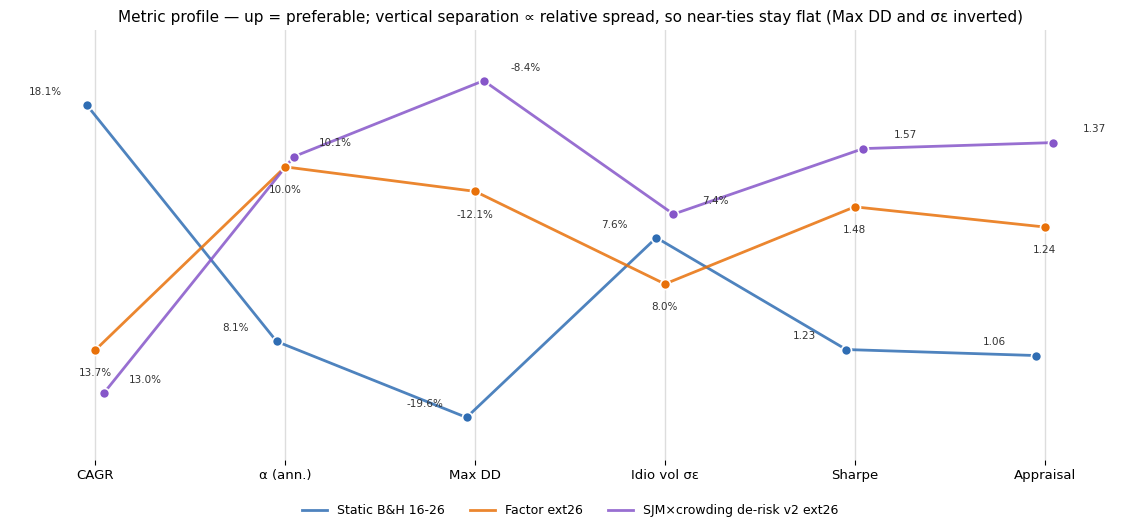

In [4]:
# SSR is deliberately NOT one of these axes: every axis here is oriented
# "up = preferable", which presumes a rankable quantity. SSR is a descriptive
# stability effect size (no sqrt(n) in its denominator), so the point estimate
# carries no inferential content — the MBB p-value/verdict above does.
PROFILE = [("CAGR", "cagr", "{:.1%}", False), ("α (ann.)", "alpha", "{:.1%}", False),
           ("Max DD", "maxdd", "{:.1%}", False),          # signed: shallow (larger) = top
           ("Idio vol σε", "idio", "{:.1%}", True),       # lower = top
           ("Sharpe", "sharpe", "{:.2f}", False), ("Appraisal", "appraisal", "{:.2f}", False)]

fig, ax = plt.subplots(figsize=(11.5, 5.4))
positions = {}
for j, (name, key, fmt, invert) in enumerate(PROFILE):
    raw = np.array([M[lbl][key] for _, lbl, _ in TRIO])
    scaled = np.full(len(raw), 0.5) if np.ptp(raw) == 0 else (raw - raw.min()) / np.ptp(raw)
    if invert:
        scaled = 1 - scaled
    # band half-width proportional to the metric's RELATIVE spread (capped at 0.40):
    # a near-tie (σε: 7.4-8.0%) must LOOK like a near-tie — plain min-max would
    # stretch a 0.6pp spread to the full band and manufacture separation from noise
    rel = np.ptp(raw) / max(1e-12, np.mean(np.abs(raw)))
    half = max(0.05, 0.40 * min(1.0, rel / 0.40))
    positions[j] = 0.5 + (scaled - 0.5) * 2 * half
    ax.axvline(j, color="#dddddd", lw=1, zorder=0)

DODGE = {0: -0.045, 1: 0.0, 2: 0.045}   # constant per-strategy x-offset: exact ties stay visible
for i, (_, lbl, color) in enumerate(TRIO):
    xs = [j + DODGE[i] for j in range(len(PROFILE))]
    ys = [positions[j][i] for j in range(len(PROFILE))]
    ax.plot(xs, ys, color=color, lw=2, zorder=2, alpha=0.85, label=lbl)
    ax.scatter(xs, ys, s=52, color=color, edgecolor="white", linewidth=1.2, zorder=3)
    lx, ly = [(-30, 6), (0, -13), (30, 6)][i]   # fixed per-strategy label slots: no collisions at ties
    for j, (name, key, fmt, invert) in enumerate(PROFILE):
        ax.annotate(fmt.format(M[lbl][key]), (xs[j], ys[j]), xytext=(lx, ly),
                    textcoords="offset points", ha="center",
                    va="bottom" if ly > 0 else "top", fontsize=7.5, color=INK)

ax.set_xticks(range(len(PROFILE)), [p[0] for p in PROFILE], fontsize=9.5)
ax.set_yticks([])
ax.set_ylim(0, 1.02)
ax.set_xlim(-0.45, len(PROFILE) - 0.55)
for side in ("left", "bottom"):
    ax.spines[side].set_visible(False)
ax.legend(loc="lower center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.16))
ax.set_title("Metric profile — up = preferable; vertical separation ∝ relative spread, "
             "so near-ties stay flat (Max DD and σε inverted)", fontsize=11)
fig.tight_layout()
fig.savefig(DATA / "nb18_metric_profile.png", dpi=300, bbox_inches="tight")
plt.show()

## Reading guide

- **Raw return:** static B&H wins CAGR — that is the cost of the de-risked seats,
  and the only axis it wins.
- **Per unit of risk:** the ordering flips on every denominator. The v2
  overlay earns the most per unit of total vol (raw-return Sharpe), per unit of
  drawdown (Calmar), and per unit of residual regression risk (Appraisal) — with
  the *lowest* risk on each axis, not by adding more.
- **Window sensitivity — read this before quoting the Calmar row.** The trio window
  ends 2026-01-30 (the static B&H series' last date). On the overlay's own full span
  to 2026-06-30 the Calmar ordering reverses: 1.147 for the overlay against 1.153
  for the unhedged base, because the overlay's worst drawdown is now a Feb–Mar 2026
  episode lying entirely outside this window. The Sharpe and max-drawdown edges do
  survive to 2026-06 (1.49 vs 1.43; −11.24% vs −12.08%). Section 2 carries the
  numbers; `15_2`'s all-lines sheet and nb17 carry the full-span rows.
- **Honesty row:** all three lines clear the one-sided MBB test at α=0.05, i.e.
  their rolling Sharpe was stably above zero *in this realized sample*. That is
  temporal consistency, not a skill claim, and it is a per-line verdict, not a
  ranking — the SSR point estimates (0.13–0.14) are descriptive effect sizes and
  the gaps between them carry no inferential meaning. The risk-adjusted ordering
  above is likewise a realized-sample statement.

Figures are written to `data/nb18_*.png` at 300 dpi for direct thesis use.
Provenance: persisted equity artifacts + the nb17 price cache; conventions and
caveats (price-only SPY regression, elapsed-calendar CAGR, √252 volatility basis)
come from the shared `macro_framework.evaluation.metric_block` that `15_2` uses.
The SJM overlay artifact is the 2026-07-27 regeneration (`signal='absorption'`,
window 126), superseding the frozen 2026-07-23 line.
